# A Computational Comparison of Prototype, Exemplar, and Rule-Based Models of Human Category Learning

**CS 6795 — Cognitive Science · Rabea Abdelwahab**

This notebook is the reproducible core of the project. It asks one falsifiable question:

> Among **prototype**, **exemplar**, and **rule** representations, which one reproduces the *way people
> generalize* — the human **difficulty ordering** of the six Shepard, Hovland & Jenkins (SHJ, 1961)
> category structures?

The benchmark is not accuracy. People learn the six structures in a stable order,

$$\mathrm{I} \;<\; \mathrm{II} \;<\; \{\mathrm{III}=\mathrm{IV}=\mathrm{V}\} \;<\; \mathrm{VI}$$

and — famously — **Type II is *unexpectedly easy*** for people, easier than the single‑feature‑plus
Types III–V. Reproducing that ordering (especially the Type II advantage) is the cognitive claim; raw
accuracy is reported but is not the thing to win on.

**Measure.** Errors‑to‑criterion learning curves, following Nosofsky, Gluck, Palmeri, McKinley &
Glauthier (1994): each *block* presents all 8 cards once, the model guesses, hears the truth, and
updates. We count errors per block over a fixed horizon and average over many simulated learners.

*Feature names (size / shape / shade) are illustrative labels for the three abstract binary
dimensions; only the structure matters.*

## 1 · Setup

In [1]:
import sys, pathlib
# Make the notebook self-locating: walk up to the repo root (where the
# `concept_learning` package lives) so it runs from anywhere.
_root = pathlib.Path.cwd()
while not (_root / "concept_learning").exists() and _root != _root.parent:
    _root = _root.parent
if str(_root) not in sys.path:
    sys.path.insert(0, str(_root))

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle, Patch
from pathlib import Path

from concept_learning.stimuli import STIMULI, N_STIMULI, N_DIMENSIONS
from concept_learning.structures import (
    TYPES, all_structures, get_structure, HUMAN_DIFFICULTY_RANK,
)
from concept_learning.experiment import run_experiment
from concept_learning.models import PrototypeModel, ALCOVEModel, RuleModel

# --- reproducible knobs (the website ships 800 subjects; 300 is plenty for the ordering) ---
N_SUBJECTS = 300
N_BLOCKS   = 25
SEED       = 0

FIG_DIR = _root / "figures"; FIG_DIR.mkdir(exist_ok=True)

plt.rcParams.update({
    "figure.dpi": 120, "savefig.dpi": 150,
    "figure.facecolor": "white", "axes.facecolor": "white",
    "axes.edgecolor": "#c9d0da", "axes.linewidth": 1.0,
    "axes.grid": True, "grid.color": "#eef1f5", "grid.linewidth": 1.0,
    "axes.spines.top": False, "axes.spines.right": False,
    "font.size": 11, "axes.titlesize": 12, "axes.titleweight": "bold",
    "font.family": "DejaVu Sans",
})
# one fixed identity colour per structure
TYPE_COLORS = {"I": "#e0a34b", "II": "#2fa8a0", "III": "#5b7fe0",
               "IV": "#d167a3", "V": "#7bab3e", "VI": "#d95f4c"}

print(f"{N_STIMULI} stimuli x {N_DIMENSIONS} binary dimensions")
print(f"{N_SUBJECTS} simulated subjects x {N_BLOCKS} blocks | seed = {SEED}")

8 stimuli x 3 binary dimensions
300 simulated subjects x 25 blocks | seed = 0


## 2 · The material — 8 cards, 6 structures

Eight cards differ on three yes/no features (2³ = 8). Every SHJ structure splits them into two piles
of four; there are exactly six such splits up to symmetry (verified by exhaustive enumeration in
`tests/test_structures.py`). The map below shows *who goes where* in each — this is the answer key the
models must reconstruct from feedback alone.

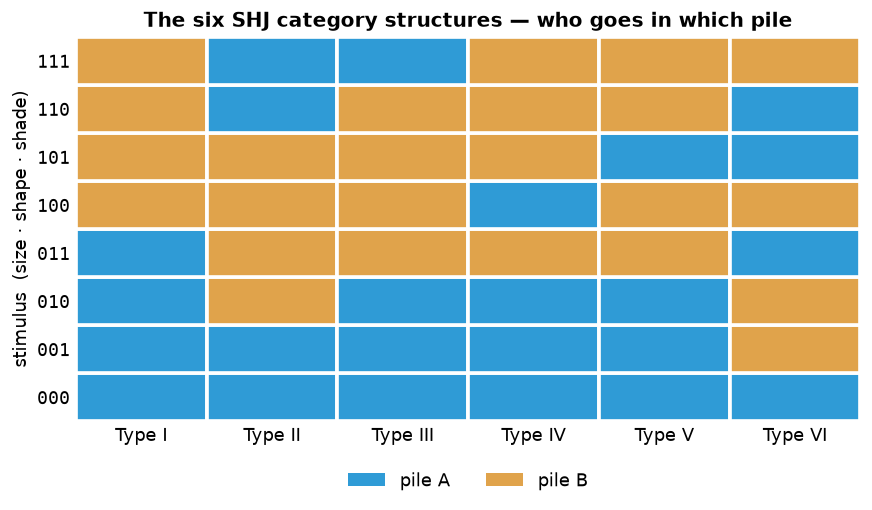

In [2]:
# Figure 0 — the six structures at a glance.
fig, ax = plt.subplots(figsize=(7.4, 4.4))
A_COL, B_COL = "#2f9bd6", "#e0a34b"
codes = ["".join(map(str, s)) for s in STIMULI]
for j, t in enumerate(TYPES):
    lab = get_structure(t).labels
    for i in range(N_STIMULI):
        ax.add_patch(Rectangle((j, i), 1, 1,
                     facecolor=A_COL if lab[i] == 0 else B_COL,
                     edgecolor="white", linewidth=2.2))
ax.set_xlim(0, len(TYPES)); ax.set_ylim(0, N_STIMULI)
ax.set_xticks(np.arange(len(TYPES)) + 0.5)
ax.set_xticklabels([f"Type {t}" for t in TYPES])
ax.set_yticks(np.arange(N_STIMULI) + 0.5)
ax.set_yticklabels(codes, fontfamily="monospace")
ax.set_ylabel("stimulus  (size · shape · shade)")
ax.tick_params(length=0); ax.grid(False)
for sp in ax.spines.values():
    sp.set_visible(False)
ax.legend(handles=[Patch(facecolor=A_COL, label="pile A"),
                   Patch(facecolor=B_COL, label="pile B")],
          ncol=2, loc="upper center", bbox_to_anchor=(0.5, -0.09), frameon=False)
ax.set_title("The six SHJ category structures — who goes in which pile")
fig.tight_layout(); fig.savefig(FIG_DIR / "fig0_structures.png", bbox_inches="tight")
plt.show()

## 3 · The models — four conditions

Each theory maps to one model. The two **exemplar** rows differ only by a single switch — whether
attention is *learned* — and that contrast is the experiment.

| condition | theory in one line |
|---|---|
| **Exemplar — attention ON** | ALCOVE: stores every instance; **learns which dimensions to attend to** |
| **Exemplar — attention OFF** | same exemplar memory, attention frozen uniform (the ablation) |
| **Prototype** | stores one *average* card per pile; classifies by similarity to it |
| **Rule (v1)** | searches for the simplest logical rule that fits |

In [3]:
CONDITIONS = {
    "exemplar_on":  ("Exemplar — attention ON",  lambda: ALCOVEModel()),
    "exemplar_off": ("Exemplar — attention OFF", lambda: ALCOVEModel(lambda_a=0.0)),
    "prototype":    ("Prototype",                lambda: PrototypeModel()),
    "rule":         ("Rule (v1: simple)",        lambda: RuleModel()),
}

# key -> {type_name -> ExperimentResult}
results = {}
for key, (label, factory) in CONDITIONS.items():
    results[key] = {st.name: run_experiment(factory, st, n_subjects=N_SUBJECTS,
                                            n_blocks=N_BLOCKS, seed=SEED)
                    for st in all_structures()}
    print(f"ran: {label}")

ran: Exemplar — attention ON


ran: Exemplar — attention OFF


ran: Prototype


ran: Rule (v1: simple)


## 4 · Difficulty by structure

In [4]:
def total_errors(key):
    return {t: results[key][t].mean_total_errors for t in TYPES}

hdr = "  ".join(f"{t:>6}" for t in TYPES)
print(f"{'model':<28}{hdr}    ordering (easy -> hard)")
print("-" * 92)
for key, (label, _) in CONDITIONS.items():
    tot = total_errors(key)
    row = "  ".join(f"{tot[t]:6.1f}" for t in TYPES)
    order = " < ".join(sorted(TYPES, key=lambda t: tot[t]))
    print(f"{label:<28}{row}    {order}")
print(f"\n{'Human (target)':<28}" + " " * (len(hdr)) + "    I < II < {III = IV = V} < VI")

model                            I      II     III      IV       V      VI    ordering (easy -> hard)
--------------------------------------------------------------------------------------------
Exemplar — attention ON       36.6    50.9    57.0    52.4    52.2    67.0    I < II < V < IV < III < VI
Exemplar — attention OFF      45.7    59.2    58.8    52.4    52.2    71.3    I < V < IV < III < II < VI
Prototype                     26.5   103.3    80.4    46.0    64.7   103.7    I < IV < V < III < II < VI
Rule (v1: simple)              1.4    53.1    52.2    51.9    52.5   101.7    I < IV < III < V < II < VI

Human (target)                                                                I < II < {III = IV = V} < VI


In [5]:
# Solve rate: fraction of learners that ever reach an error-free block within the horizon.
print("P(reached criterion) within horizon — note the prototype's blindness on II & VI:\n")
print(f"{'model':<28}" + "  ".join(f"{t:>6}" for t in TYPES))
print("-" * 76)
for key, (label, _) in CONDITIONS.items():
    row = "  ".join(f"{results[key][t].p_reached_criterion:6.2f}" for t in TYPES)
    print(f"{label:<28}{row}")

P(reached criterion) within horizon — note the prototype's blindness on II & VI:

model                            I      II     III      IV       V      VI
----------------------------------------------------------------------------
Exemplar — attention ON       1.00    1.00    0.95    0.98    0.99    0.76
Exemplar — attention OFF      1.00    0.93    0.91    0.99    0.98    0.65
Prototype                     1.00    0.08    0.24    0.93    0.60    0.07
Rule (v1: simple)             1.00    0.79    0.00    0.92    0.81    0.12


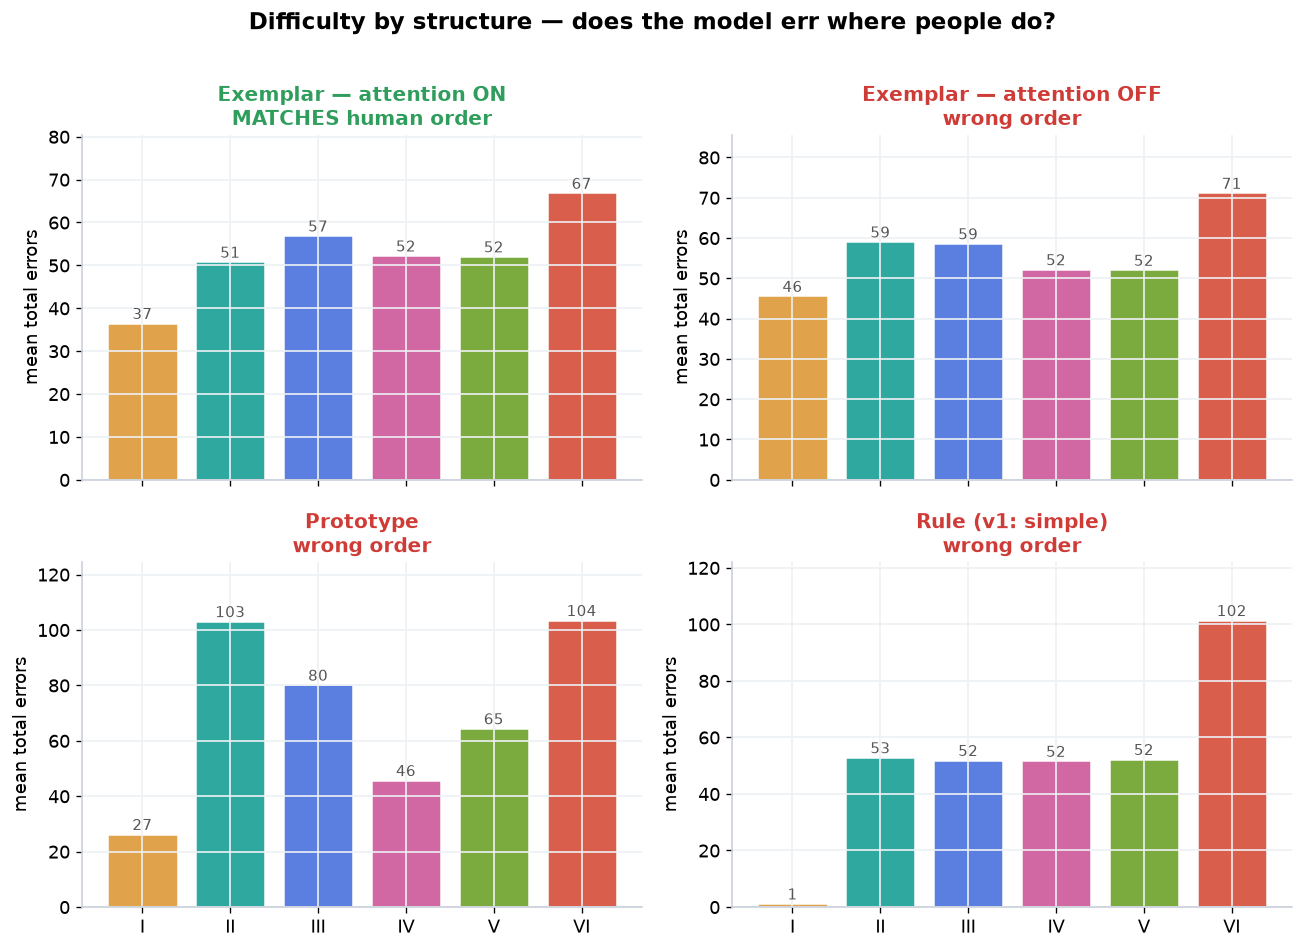

In [6]:
# Figure 1 — headline: total errors per structure, one panel per model.
def reproduces_human(tot):
    band = np.mean([tot["III"], tot["IV"], tot["V"]])
    return tot["I"] < tot["II"] < band < tot["VI"]

fig, axes = plt.subplots(2, 2, figsize=(11, 7.8), sharex=True)
for ax, (key, (label, _)) in zip(axes.flat, CONDITIONS.items()):
    tot = total_errors(key)
    bars = ax.bar(TYPES, [tot[t] for t in TYPES],
                  color=[TYPE_COLORS[t] for t in TYPES],
                  edgecolor="white", linewidth=1.5)
    for t, b in zip(TYPES, bars):
        ax.text(b.get_x() + b.get_width() / 2, b.get_height(), f"{tot[t]:.0f}",
                ha="center", va="bottom", fontsize=9, color="#555")
    ok = reproduces_human(tot)
    ax.set_title(f"{label}\n{'MATCHES human order' if ok else 'wrong order'}",
                 color="#2f9d5b" if ok else "#cf3b36")
    ax.set_ylabel("mean total errors"); ax.margins(y=0.2)
fig.suptitle("Difficulty by structure — does the model err where people do?",
             fontsize=14, fontweight="bold", y=1.01)
fig.tight_layout(); fig.savefig(FIG_DIR / "fig1_difficulty.png", bbox_inches="tight")
plt.show()

**Reading Figure 1.** Only the exemplar model *with learned attention* puts the structures in the human
order — with Type II tucked below the III–V band. Prototype blows up on the two structures whose
category averages coincide (II, VI). The rule seeker aces the single‑feature Type I but finds the
XOR‑like Type II hard — the opposite of people.

## 5 · Learning curves

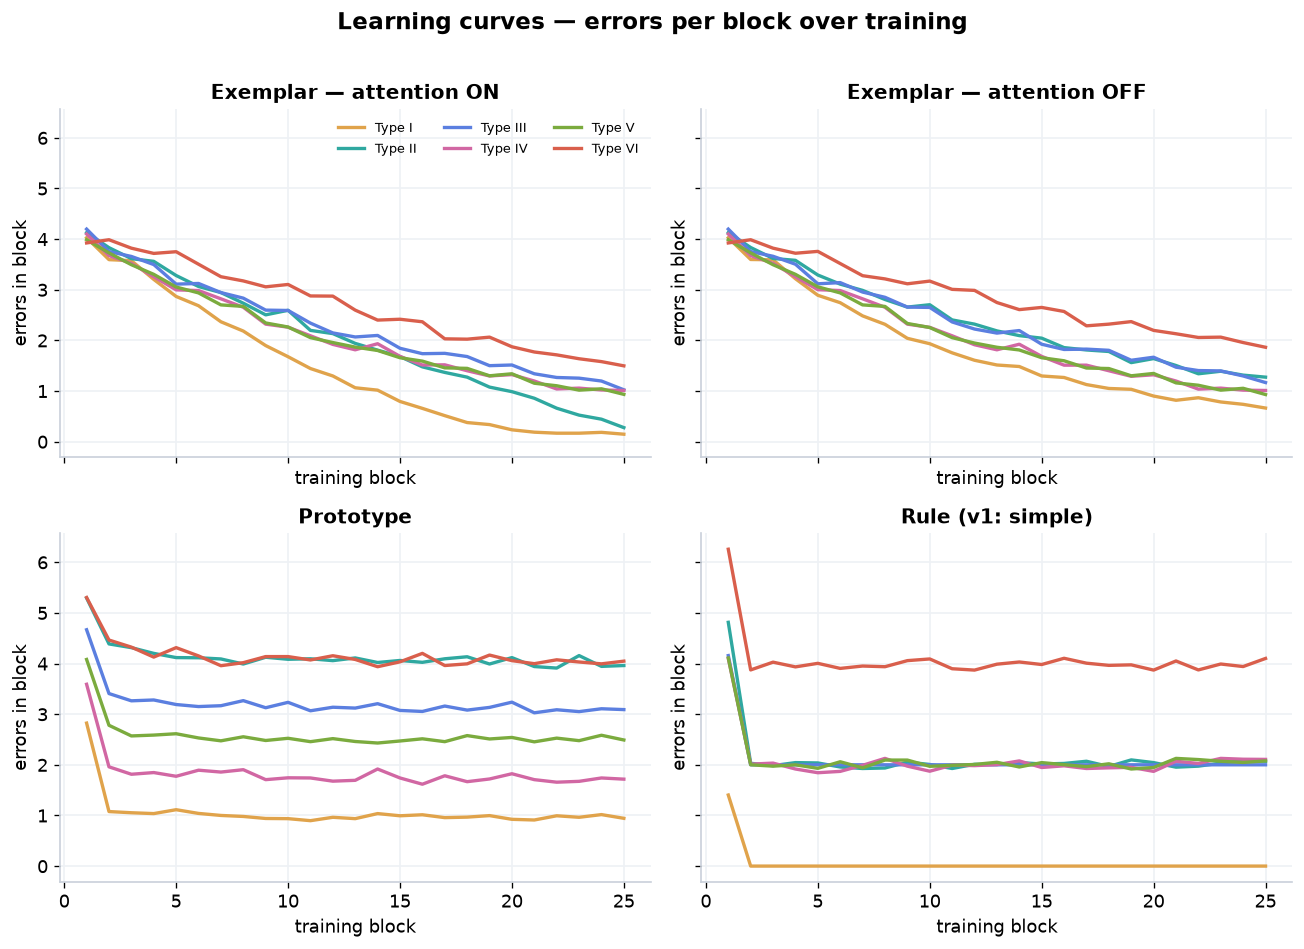

In [7]:
# Figure 2 — errors per block over training, one panel per model.
fig, axes = plt.subplots(2, 2, figsize=(11, 7.8), sharex=True, sharey=True)
for ax, (key, (label, _)) in zip(axes.flat, CONDITIONS.items()):
    for t in TYPES:
        ax.plot(range(1, N_BLOCKS + 1), results[key][t].mean_errors_per_block,
                color=TYPE_COLORS[t], lw=2, label=f"Type {t}")
    ax.set_title(label); ax.set_xlabel("training block"); ax.set_ylabel("errors in block")
axes.flat[0].legend(ncol=3, fontsize=8, frameon=False, loc="upper right")
fig.suptitle("Learning curves — errors per block over training",
             fontsize=14, fontweight="bold", y=1.01)
fig.tight_layout(); fig.savefig(FIG_DIR / "fig2_curves.png", bbox_inches="tight")
plt.show()

## 6 · The attention ablation — the whole thesis in one switch

The two exemplar conditions are identical except for the attention‑learning rate. Turning attention
**off** is enough to destroy the Type II advantage: with attention frozen the model can only re‑weight
its stored links, never learn to *ignore* the irrelevant third feature — so Type II is no longer easy.

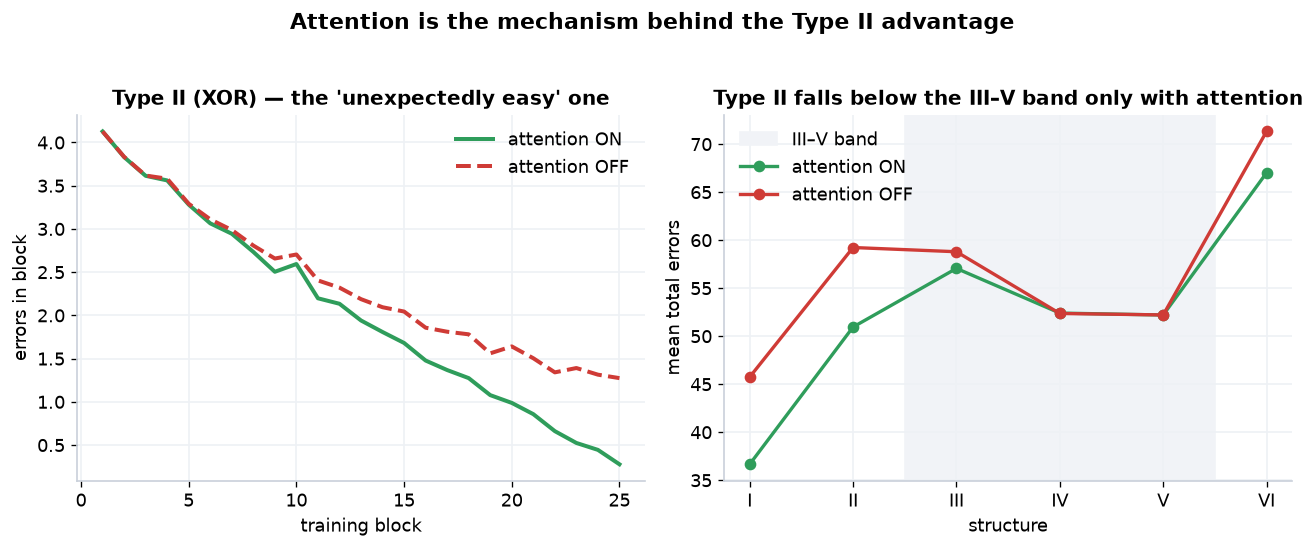

In [8]:
# Figure 3 — attention on vs off, focused on Type II.
NAMES = {"exemplar_on": "attention ON", "exemplar_off": "attention OFF"}
fig, (axL, axR) = plt.subplots(1, 2, figsize=(11, 4.4))

for key, c, ls in [("exemplar_on", "#2f9d5b", "-"), ("exemplar_off", "#cf3b36", "--")]:
    axL.plot(range(1, N_BLOCKS + 1), results[key]["II"].mean_errors_per_block,
             color=c, lw=2.4, ls=ls, label=NAMES[key])
axL.set_title("Type II (XOR) — the 'unexpectedly easy' one")
axL.set_xlabel("training block"); axL.set_ylabel("errors in block")
axL.legend(frameon=False)

x = np.arange(len(TYPES))
axR.axvspan(1.5, 4.5, color="#f1f3f7", zorder=0, label="III–V band")  # the III-IV-V band
for key, c in [("exemplar_on", "#2f9d5b"), ("exemplar_off", "#cf3b36")]:
    tot = total_errors(key)
    axR.plot(x, [tot[t] for t in TYPES], "o-", color=c, lw=2, label=NAMES[key])
axR.set_xticks(x); axR.set_xticklabels(TYPES)
axR.set_title("Type II falls below the III–V band only with attention")
axR.set_xlabel("structure"); axR.set_ylabel("mean total errors"); axR.legend(frameon=False)

fig.suptitle("Attention is the mechanism behind the Type II advantage",
             fontsize=13, fontweight="bold", y=1.03)
fig.tight_layout(); fig.savefig(FIG_DIR / "fig3_attention.png", bbox_inches="tight")
plt.show()

## 7 · Verdict — quantitative fit to the human ordering

In [9]:
# Rank correlation between each model's errors and the human difficulty rank,
# plus the strict "matches human order" test used above.
def spearman(a, b):
    ar = np.argsort(np.argsort(a)).astype(float)
    br = np.argsort(np.argsort(b)).astype(float)
    ar -= ar.mean(); br -= br.mean()
    return float((ar @ br) / np.sqrt((ar @ ar) * (br @ br)))

human = np.array([HUMAN_DIFFICULTY_RANK[t] for t in TYPES], float)
print(f"{'model':<28}{'rank corr':>11}   reproduces I<II<{{III,IV,V}}<VI ?")
print("-" * 70)
for key, (label, _) in CONDITIONS.items():
    tot = total_errors(key)
    errs = np.array([tot[t] for t in TYPES])
    rho = spearman(errs, human)
    print(f"{label:<28}{rho:>11.3f}   {'YES' if reproduces_human(tot) else 'no'}")
print("\n(rank corr = Spearman-style correlation of model errors vs human difficulty rank;")
print(" human ranks are tied for III/IV/V, so the strict test on the right is the decisive one.)")

model                         rank corr   reproduces I<II<{III,IV,V}<VI ?
----------------------------------------------------------------------
Exemplar — attention ON           0.771   YES
Exemplar — attention OFF          0.429   no
Prototype                         0.486   no
Rule (v1: simple)                 0.600   no

(rank corr = Spearman-style correlation of model errors vs human difficulty rank;
 human ranks are tied for III/IV/V, so the strict test on the right is the decisive one.)


## 8 · Conclusion

- **Only the exemplar model with learned selective attention** reproduces the human difficulty
  ordering, including the signature **Type II advantage**.
- The **attention‑off ablation** shows attention is precisely the mechanism: freeze it and the Type II
  advantage disappears while everything else is unchanged.
- The **prototype** model is structurally blind to Types II and VI (its two category averages coincide),
  and the **rule** model finds the XOR‑like Type II hard — the opposite of people — even though it
  solves the single‑feature Type I almost instantly.

This is an informative *positive* result for the exemplar‑plus‑attention account of human concepts.

**Next (per the project plan):** the Medin & Schaffer (1978) 5‑4 secondary check (task 11), which
historically separates prototype from exemplar accounts and tests whether the exemplar advantage is
specific or general. It uses a 4‑dimensional stimulus set and so requires dimension‑general versions of
the three models — the natural next increment on top of this core.

### References
1. Shepard, Hovland & Jenkins (1961). *Psychological Monographs*, 75(13).
2. Nosofsky, Gluck, Palmeri, McKinley & Glauthier (1994). *Memory & Cognition*, 22(3).
3. Medin & Schaffer (1978). *Psychological Review*, 85(3).
4. Nosofsky (1986). *J. Exp. Psychol.: General*, 115(1). · Kruschke (1992), ALCOVE. *Psych. Review*, 99(1).